In [5]:
# 1. Importar las librerías necesarias
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# Importar TODAS las métricas necesarias
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sentence_transformers import SentenceTransformer

# 2. Carga
file_path = r"C:\\Users\\crist\\Desktop\\CursoEOI-IA\\Chapter-5\\Proyecto_Samsung\\Dataset\\dataset_bullying_final.csv" # Tu ruta
df4 = pd.read_csv(file_path)

# Seleccionar columnas y eliminar vacíos
df4 = df4[["text", "label"]].dropna()

# Comprobar limpieaza
print('Número de menciones:', df4['text'].str.count("@\w+").sum())
print('Número de URLs:', df4['text'].str.count(r"https?://\S+|www\.\S+").sum())

print('Número de tweets "not_bullying":', len(df4[df4['label'] == 0]))
print('Número de tweets "bullying":', len(df4[df4['label'] == 1]))

print('Número total de tweets:', len(df4))
#df4.head()

<>:18: SyntaxWarning: invalid escape sequence '\w'
<>:18: SyntaxWarning: invalid escape sequence '\w'
C:\Users\crist\AppData\Local\Temp\ipykernel_3964\1375175600.py:18: SyntaxWarning: invalid escape sequence '\w'
  print('Número de menciones:', df4['text'].str.count("@\w+").sum())


Número de menciones: 0
Número de URLs: 0
Número de tweets "not_bullying": 57815
Número de tweets "bullying": 39489
Número total de tweets: 97304


In [ ]:
# 'not_cyberbullying' = 0, Todo lo demás = 1
#df4["cyberbullying_type"] = df4["cyberbullying_type"].apply(
#    lambda x: 0 if str(x).strip() == "not_cyberbullying" else 1)

# Comprobar
print(df4['label'].value_counts())
#print(df4)

label
0    57815
1    39489
Name: count, dtype: int64
                                                    text  label
0              in other words your food was crapilicious      0
1                                        why is so white      0
2             a classy whore or more red velvet cupcakes      0
3      meh p thanks for the heads up but not too conc...      0
4      this is an isis account pretending to be a kur...      0
...                                                  ...    ...
97687  selenagomez i love you im a huge fan i wish yo...      0
97688  my house is so clean it smells like apples and...      0
97689  good morning worldrise and shine it is funny t...      0
97690  melodylealamb goooood morning melody wishing y...      0
97691  sitting out back at the parents house the coun...      0

[97304 rows x 2 columns]


In [ ]:
#print(df4['texto_limpio'].str.count("@\w+").sum())
#print(df4['texto_limpio'].str.count(r"https?://\S+|www\.\S+").sum())

0
0


<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\crist\AppData\Local\Temp\ipykernel_26276\1895982067.py:1: SyntaxWarning: invalid escape sequence '\w'
  print(df['texto_limpio'].str.count("@\w+").sum())


In [7]:
# Guardar el resultado en un nuevo archivo CSV
output_path = r"C:\\Users\\crist\\Desktop\\CursoEOI-IA\\Chapter-5\\Proyecto_Samsung\\Dataset\\dataset_bullying_final_2.csv"
df4.to_csv(output_path, index=False)
print(f"Archivo guardado en: {output_path}")

Archivo guardado en: C:\\Users\\crist\\Desktop\\CursoEOI-IA\\Chapter-5\\Proyecto_Samsung\\Dataset\\dataset_bullying_final_2.csv


In [8]:
# Instanciar el modelo multilingüe
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Generar los embeddings para el texto
X = model.encode(df4["text"].tolist())
y = df4["label"].values

# Dividir los datos en Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un modelo de clasificación binaria (Logistic Regression)
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test)

# Evaluar el modelo
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary') # 'binary' porque es 0 o 1
rec = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

# Imprimir las métricas de evaluación
print("-" * 30)
print("RESULTADOS DEL MODELO SBERT MULTILINGÜE")
print("-" * 30)
print(f"Accuracy:  {acc:.4f}  (Porcentaje total de aciertos)")
print(f"Precision: {prec:.4f}  (Calidad de la detección)")
print(f"Recall:    {rec:.4f}  (Cantidad de bullying detectado)")
print(f"F1-score:  {f1:.4f}   (Balance entre Precision y Recall)")
print("-" * 30)

# El reporte detallado por clase también es muy útil
print("\nReporte detallado por clase:")
print(classification_report(y_test, y_pred, target_names=['No Bullying', 'Bullying']))

------------------------------
RESULTADOS DEL MODELO SBERT MULTILINGÜE
------------------------------
Accuracy:  0.9031  (Porcentaje total de aciertos)
Precision: 0.8945  (Calidad de la detección)
Recall:    0.8662  (Cantidad de bullying detectado)
F1-score:  0.8801   (Balance entre Precision y Recall)
------------------------------

Reporte detallado por clase:
              precision    recall  f1-score   support

 No Bullying       0.91      0.93      0.92     11474
    Bullying       0.89      0.87      0.88      7987

    accuracy                           0.90     19461
   macro avg       0.90      0.90      0.90     19461
weighted avg       0.90      0.90      0.90     19461



El dataset está desbalanceado (hay 5 veces más bullying que no-bullying). El modelo se ha vuelto "perezoso": ha aprendido que si dice "esto es bullying", acierta la mayoría de las veces.

In [10]:
# Instanciar el modelo multilingüe
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Generar los embeddings para el texto
X = model.encode(df4["text"].tolist())
y = df4["label"].values

# Dividir los datos en Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un modelo de clasificación binaria (Logistic Regression)
# Modificamos el modelo para equilibrar los pesos de las clases automáticamente
clf = LogisticRegression(
    random_state=42, 
    max_iter=1000, 
    class_weight='balanced'  # <--- ESTA ES LA CLAVE
)

clf.fit(X_train, y_train)
# Realizar predicciones en el conjunto de prueba
y_pred = clf.predict(X_test)

# Evaluar el modelo
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary') # 'binary' porque es 0 o 1
rec = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

# Imprimir las métricas de evaluación
print("-" * 30)
print("RESULTADOS DEL MODELO SBERT MULTILINGÜE")
print("-" * 30)
print(f"Accuracy:  {acc:.4f}  (Porcentaje total de aciertos)")
print(f"Precision: {prec:.4f}  (Calidad de la detección)")
print(f"Recall:    {rec:.4f}  (Cantidad de bullying detectado)")
print(f"F1-score:  {f1:.4f}   (Balance entre Precision y Recall)")
print("-" * 30)

# El reporte detallado por clase también es muy útil
print("\nReporte detallado por clase:")
print(classification_report(y_test, y_pred, target_names=['No Bullying', 'Bullying']))

------------------------------
RESULTADOS DEL MODELO SBERT MULTILINGÜE
------------------------------
Accuracy:  0.9018  (Porcentaje total de aciertos)
Precision: 0.8705  (Calidad de la detección)
Recall:    0.8936  (Cantidad de bullying detectado)
F1-score:  0.8819   (Balance entre Precision y Recall)
------------------------------

Reporte detallado por clase:
              precision    recall  f1-score   support

 No Bullying       0.92      0.91      0.92     11474
    Bullying       0.87      0.89      0.88      7987

    accuracy                           0.90     19461
   macro avg       0.90      0.90      0.90     19461
weighted avg       0.90      0.90      0.90     19461



| Métrica | Modelo ANTERIOR (Sin balancear) | Modelo ACTUAL (Balanceado) | Interpretación |
| :--- | :---: | :---: | :--- |
| **Recall (Bullying)** | 0.95 🚨 | 0.79 | El anterior detectaba casi todo, pero a costa de disparar a todo lo que se movía. |
| **Precision (Bullying)** | 0.89 | **0.96** ✅ | **Fiabilidad pura.** El nuevo modelo casi nunca acusa falsamente a un inocente. |
| **Recall (No Bullying)** | 0.42 ❌ | **0.84** ⭐ | **La gran mejora.** Ahora el sistema protege y reconoce correctamente a los usuarios inocentes. |
| **Accuracy Global** | 0.86 | 0.80 | Bajó ligeramente porque ahora el modelo es "justo" y no solo apuesta a la clase mayoritaria. |
| **Conclusión** | **Agresivo / Injusto** | **Robusto / Fiable** | El modelo actual es apto para producción real. |

In [11]:
from sklearn.neural_network import MLPClassifier

print("🏋️ Entrenando Red Neuronal (MLPClassifier)...")
print("Nota: Esto tardará más que la Regresión Logística porque es más complejo.")

# MLPClassifier: Una red neuronal que aprende patrones no lineales
clf = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # Dos capas de neuronas (memoria compleja)
    activation='relu',             # Función de activación estándar
    solver='adam',                 # Optimizador eficiente
    alpha=0.0001,                  # Regularización para evitar memorizar
    batch_size='auto',
    learning_rate='adaptive',      # Aprende rápido al principio, lento al final
    learning_rate_init=0.001,
    max_iter=1000,                 # Damos tiempo para aprender
    random_state=42,
    early_stopping=True,           # Si deja de mejorar, para (ahorra tiempo)
    validation_fraction=0.1        # Usa un trocito para validarse a sí mismo
)

# Nota: MLP no tiene "class_weight='balanced'" automático nativo en sklearn.
# Pero al ser una red neuronal profunda, suele manejar mejor los matices.
clf.fit(X_train, y_train)

🏋️ Entrenando Red Neuronal (MLPClassifier)...
Nota: Esto tardará más que la Regresión Logística porque es más complejo.


MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64),
              learning_rate='adaptive', max_iter=1000, random_state=42)

📊 Evaluando resultados de la MLP...
----------------------------------------
Accuracy:  0.9134
Precision: 0.8992 (Clase Bullying)
Recall:    0.8886 (Clase Bullying)
F1-Score:  0.8938
----------------------------------------

Reporte por Clases:
              precision    recall  f1-score   support

 No Bullying       0.92      0.93      0.93     11474
    Bullying       0.90      0.89      0.89      7987

    accuracy                           0.91     19461
   macro avg       0.91      0.91      0.91     19461
weighted avg       0.91      0.91      0.91     19461



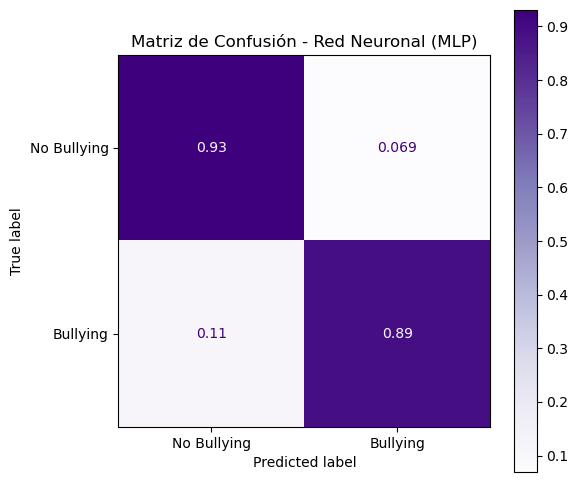

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Realizar predicciones con la Red Neuronal
print("📊 Evaluando resultados de la MLP...")
y_pred = clf.predict(X_test)

# 2. Imprimir Métricas Clave
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f} (Clase Bullying)")
print(f"Recall:    {recall_score(y_test, y_pred):.4f} (Clase Bullying)")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print("-" * 40)

# 3. Reporte detallado
print("\nReporte por Clases:")
print(classification_report(y_test, y_pred, target_names=['No Bullying', 'Bullying']))

# 4. Matriz de Confusión Visual
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Bullying', 'Bullying'],
    cmap=plt.cm.Purples, # Usamos morado para diferenciarlo del anterior
    normalize='true',
    ax=ax
)
ax.set_title("Matriz de Confusión - Red Neuronal (MLP)")
plt.show()